bordes
udd4

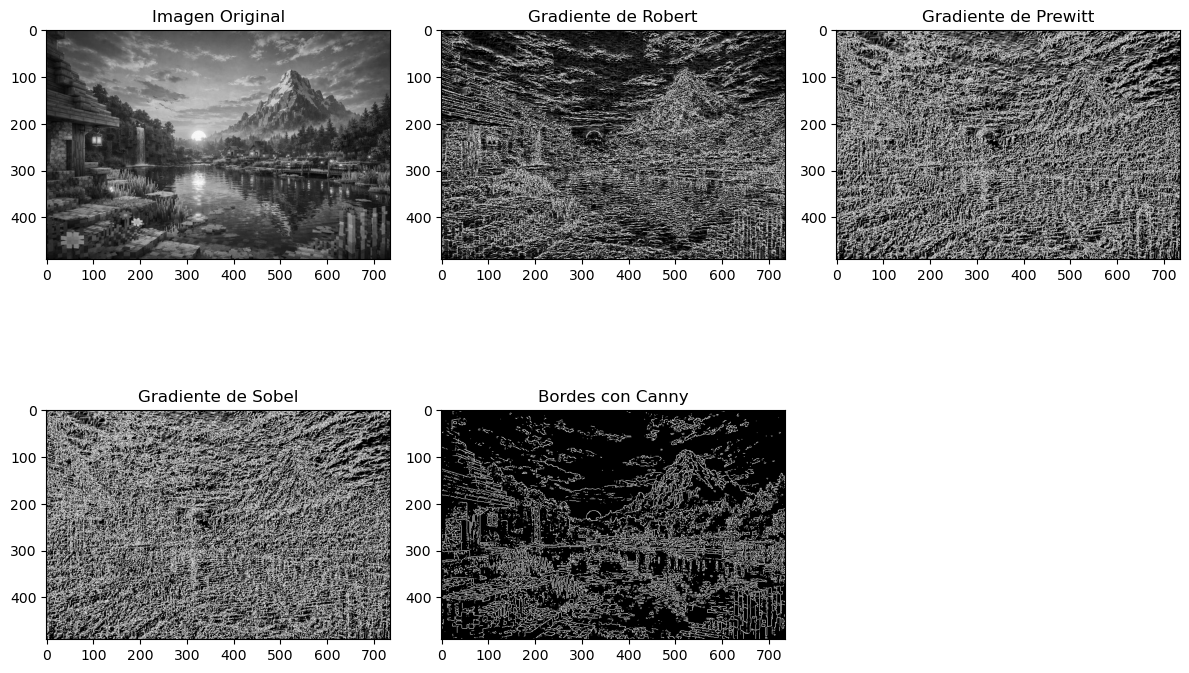

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('paisaje.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
robertx=np.array([[-1,0],[0,1]])
roberty=np.array([[0,-1],[1,0]])
robx_img=cv2.filter2D(gray,-1,robertx)
roby_img=cv2.filter2D(gray,-1,roberty)
rob_grad=np.sqrt(robx_img**2+roby_img**2)
rob_grad_dir=np.arctan2(robx_img, roby_img)

#prewit
prewitt_x=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitt_y=np.array([[-1,-1,-1],[0,0,0],[1,1,1]])
prex_img=cv2.filter2D(gray,-1,prewitt_x)
prey_img=cv2.filter2D(gray,-1,prewitt_y)
prewitt_mag=np.sqrt(prex_img**2+prey_img**2)
preww_dir=np.arctan2(prex_img, prey_img)


#sobel
sobel_x=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y=np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
sobelx_img=cv2.filter2D(gray,-1,sobel_x)
sobely_img=cv2.filter2D(gray,-1,sobel_y)
sobel_mag=np.sqrt(sobelx_img**2+sobely_img**2)
sobel_dir=np.arctan2(sobelx_img, sobely_img)

cany_img=cv2.Canny(gray,100,100)

plt.figure(figsize=(12,8))
plt.subplot(2,3,1), plt.imshow(gray, cmap='gray'), plt.title('Imagen Original')
plt.subplot(2,3,2), plt.imshow(rob_grad, cmap='gray'), plt.title('Gradiente de Robert')
plt.subplot(2,3,3), plt.imshow(prewitt_mag, cmap='gray'), plt.title('Gradiente de Prewitt')
plt.subplot(2,3,4), plt.imshow(sobel_mag, cmap='gray'), plt.title('Gradiente de Sobel')
plt.subplot(2,3,5), plt.imshow(cany_img, cmap='gray'), plt.title('Bordes con Canny')

plt.show()

sobel

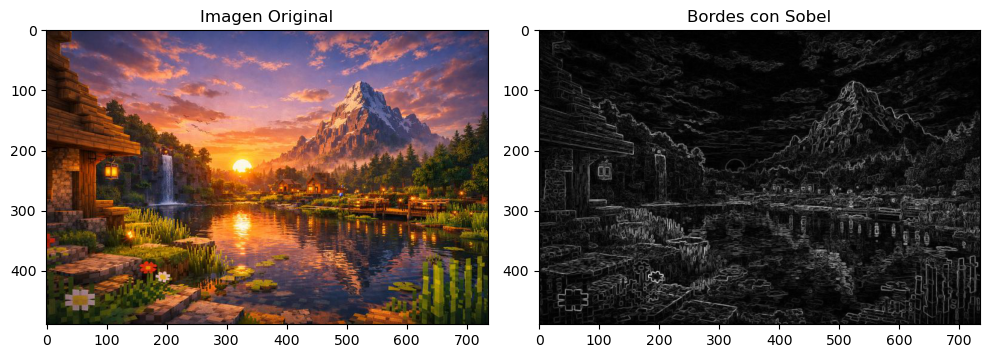

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    g_x= cv2.Sobel(img_gris, cv2.CV_64F, 1,0, ksize=3)
    g_y= cv2.Sobel(img_gris, cv2.CV_64F, 0,1, ksize=3)

    mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    return mag

img=cv2.imread('paisaje.jpg')
sobel_result=filtro_sobel(img)
plt.figure(figsize=(10,6))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Imagen Original')
plt.subplot(1,2,2), plt.imshow(sobel_result, cmap='gray'), plt.title('Bordes con Sobel')

plt.show()

sobel mejorado 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel_mejorado(img, kernel_size=3, umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #para mejrpar la direccion filtro gauss
    img_gris= cv2.GaussianBlur(img_gris,(3,3),0)


    g_x= cv2.Sobel(img_gris, cv2.CV_64F, 1,0, ksize=kernel_size)
    g_y= cv2.Sobel(img_gris, cv2.CV_64F, 0,1, ksize=kernel_size)


    #mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=np.sqrt(g_x**2 + g_y**2)
    mag=cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _,bordes=cv2.threshold(mag, umbral, 255, cv2.THRESH_BINARY+ cv2.THRES_OTSU)
    #operacion morfologica para unir bordes rotos
    kernel_m=np.ones((2,2), np.uint8)
    bordes= cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_m)
    return bordes

img=cv2.imread('paisaje.jpg')
sobel_mejorado=filtro_sobel_mejorado(img, kernel_size=3, umbral=30)
plt.figure(figsize=(10,6))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Imagen Original')
plt.subplot(1,2,2), plt.imshow(sobel_mejorado, cmap='gray'), plt.title('Bordes con Sobel Mejorado')

plt.show()


AttributeError: module 'cv2' has no attribute 'THRES_OTSU'

robert mejorado

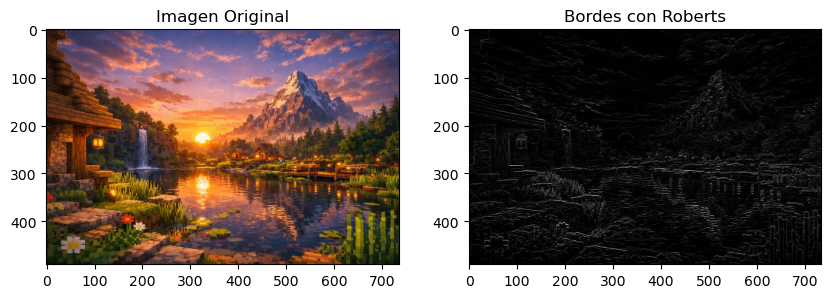

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    robertx=np.array([[-1,0],[0,1]], dtype=np.float32)
    roberty=np.array([[0,-1],[1,0]], dtype=np.float32)
    r_x=cv2.filter2D(img_gris, -1, robertx)
    r_y=cv2.filter2D(img_gris, -1, roberty)
    roberts=cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)
    return roberts

img=cv2.imread('paisaje.jpg')
roberts_result=filtro_roberts(img)
plt.figure(figsize=(10,6))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Imagen Original')
plt.subplot(1,2,2), plt.imshow(roberts_result, cmap='gray'), plt.title('Bordes con Roberts')

plt.show()